<font style='font-size:1.5em'>**Data Cleaning and Data Analysis of our Coursework** </font>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint
from tqdm.notebook import tqdm

from functions import *

from sqlalchemy import create_engine
import mysql.connector
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
import plotly.express as px
from tabulate import tabulate

import plotly.io as pio
pio.renderers = "notebook_connected"

c:\Users\Ibrahim\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
engine = create_engine('sqlite:///../data/states_reddit.db', echo=False, isolation_level="AUTOCOMMIT")

with engine.connect() as conn:
    pass

In [3]:
%load_ext sql
%sql sqlite:///../states_reddit.db --states_data

# Part I: Data Cleaning

In [4]:
# Extracting the title and the content of the post and removing the stopwords of the text data 
# of each state subreddit and putting it in a dictionary.

state_data = pd.read_sql('SELECT * FROM states_data' , engine)
clean_data= {}
for state in subreddits:
    clean_data[state] = clean_text(state_data,state)

In [ ]:
# Create an empty dictionary to store sample counts for each state
sample_counts = {}

# Iterate over each state and its corresponding cleaned data
for state, data in clean_data.items():
    # Count the number of samples for the current state
    sample_count = len(data)
    
    # Store the sample count for the current state
    sample_counts[state] = sample_count

# Print the sample counts for each state
for state, count in sample_counts.items():
    print(f"State: {state}, Sample Count: {count}")


# Part II: Data Modelling

In [5]:
# A function that creates a BERTopic model of a state and putting the model into the dictionary

models = {}

def modelling (state,text):
    
    vectorizer_model = CountVectorizer(stop_words="english")
    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
    model = BERTopic(

        embedding_model='all-MiniLM-L6-v2',
        low_memory=True,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer_model,
        representation_model = MaximalMarginalRelevance(diversity=0.2)

    )
    
    topic, prob = model.fit_transform(text)
    models[state] = model


In [6]:
# Create BERTopic models for every state and put inside the dictionary "models"
# Expected runtime is around 13 minutes

for state, data in clean_data.items():
    modelling(state,data)

In [ ]:

# Create an empty dictionary to store the models and results for each subreddit
grouped_data = state_data.groupby('subreddit').agg({
    'title': list,
    'selftext': list,
    'num_comments': list
})

# Create an empty dictionary to store the models and results for each subreddit
subreddit_models = {}

# Iterate over each subreddit and its corresponding grouped data
for subreddit, data in grouped_data.iterrows():
    # Combine the titles and selftext into a single list
    combined_text = data['title'] + data['selftext']
    
    # Create a BERTopic model instance
    vectorizer_model = CountVectorizer(stop_words="english", min_df=3)
    model = BERTopic(embedding_model='all-MiniLM-L6-v2',low_memory=True)
    
    # Fit the model to the combined text
    topics, probabilities = model.fit_transform(combined_text)
    
    # Store the model and results for the current subreddit
    subreddit_models[subreddit] = {'model': model, 'topics': topics, 'probabilities': probabilities}


# Part III: Data Analysis

## State 1 - Arkansas 

In [83]:
# Gets the common topics of r/Arkansas
models['Arkansas'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,207,-1_told_walmart_ozarks_bradford,"[told, walmart, ozarks, bradford, office, town...",[Many good things came Ozarks Program recently...
1,0,99,0_sanders_huckabee_governor_audit,"[sanders, huckabee, governor, audit, foia, gov...",[I sorry outsiders want know cool stuff reason...
2,1,73,1_happy_halloween_heart_unmatched,"[happy, halloween, heart, unmatched, mask, unp...","[What really look like, Happy Halloween, Stole..."
3,2,45,2_baptist_arrested_ar_church,"[baptist, arrested, ar, church, sentenced, pri...",[Rogers man arrested threatening rape kill Gov...
4,3,35,3_abortion_hemp_ballot_marijuana,"[abortion, hemp, ballot, marijuana, signatures...",[I collecting signatures Arkansas Abortion Ame...
5,4,27,4_schools_teachers_public_bigot,"[schools, teachers, public, bigot, applicants,...",[By school year fully privatizes public educat...
6,5,25,5_pictures_lake_ouachita_conway,"[pictures, lake, ouachita, conway, zoo, bella,...","[Picture I took evening Little Rock, photo I t..."
7,6,24,6_cotton_hutchinson_fox_tom,"[cotton, hutchinson, fox, tom, trump, maga, em...",[Asa Hutchinson Relentlessly Booed Jeered By M...
8,7,24,7_library_coulter_librarians_county,"[library, coulter, librarians, county, books, ...",[Saline County Library Director Fired Refusing...
9,8,24,8_1864_sphinx_stores_grew,"[1864, sphinx, stores, grew, veteran, lynch, n...",[Undeterred racist Black Santa brings cheer Ar...


In [84]:
# pulls a couple of docs aka title or subtexts that represent the chosen topic
models['Arkansas'].get_representative_docs(1)

['What really look like', 'Happy Halloween', 'Stolen Happy Halloween']

In [85]:
# creates a cluster plot of texts and their respective topics/ interactive
arkansas_fig_topics = models['Arkansas'].visualize_topics()
arkansas_fig_topics.show()

with open('../docs/code_analysis/bert_files/arkansas/arkansas-topic-map.html', 'w') as f:
    f.write(arkansas_fig_topics.to_html(include_plotlyjs='cdn'))


In [86]:
# Creates a hierarchical clustering figure of r/Arkansas
arkansas_fig_hierarchy = models['Arkansas'].visualize_hierarchy()
arkansas_fig_hierarchy.show()

with open('../docs/code_analysis/bert_files/arkansas/arkansas-topic-hierarchy.html', 'w') as f:
    f.write(arkansas_fig_hierarchy.to_html(include_plotlyjs='cdn'))

In [87]:
# This code generates a bar chart visualization of the top 10 topics for the 'Arkansas' subreddit.
arkansas_fig_barchart = models['Arkansas'].visualize_barchart(top_n_topics=10)
arkansas_fig_barchart.show()

with open('../docs/code_analysis/bert_files/arkansas/arkansas-topic-bar.html', 'w') as f:
    f.write(arkansas_fig_barchart.to_html(include_plotlyjs='cdn'))

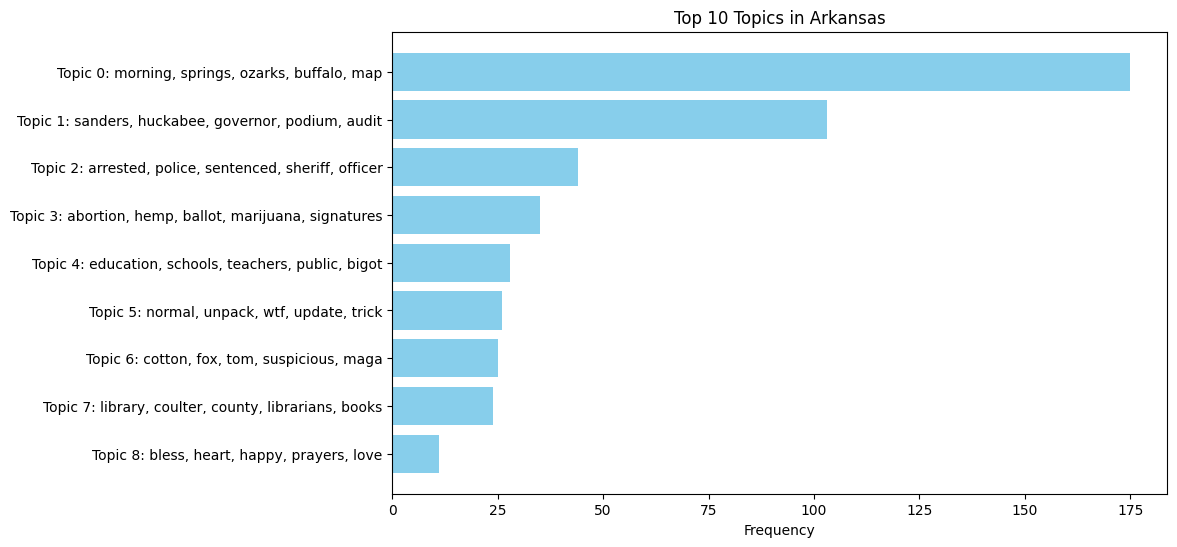

In [61]:
#| label: arkansas-top-topics
import matplotlib.pyplot as plt

arkansas_model = models['Arkansas']
topics_info = arkansas_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in arkansas_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart 
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Arkansas')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()


In [88]:
# Create a heatmap, showing how similar the topics are to each other of r/Arkansas
arkansas_fig_heatmap = models['Arkansas'].visualize_heatmap()
arkansas_fig_heatmap.show()
with open('../docs/code_analysis/bert_files/arkansas/arkansas-topic-heatmap.html', 'w') as f:
    f.write(arkansas_fig_heatmap.to_html(include_plotlyjs='cdn'))

# State 2 - Texas

In [7]:
# Gets the common topics of r/texas
models["texas"].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,173,-1_kids_indoctrination_border_shouldn,"[kids, indoctrination, border, shouldn, campai...","[edit3: I don't know I bothered. She right, I ..."
1,0,55,0_arrest_tesla_mccauley_employee,"[arrest, tesla, mccauley, employee, threat, mu...","[Luke Garrett Resecker, 18, grinned new mugsho..."
2,1,46,1_schools_public_teachers_voucher,"[schools, public, teachers, voucher, education...",[Just moved PA middle school aged kid can't pl...
3,2,36,2_driving_road_drivers_storm,"[driving, road, drivers, storm, wildflowers, r...",[The wildflowers full bloom Central Texas. Alo...
4,3,35,3_greg_abbott_pardon_aid,"[greg, abbott, pardon, aid, gov, statutes, wil...",[🚨The Texas National Guard responds Supreme Co...
5,4,33,4_heb_giggling_headline_smh,"[heb, giggling, headline, smh, spread, twitter...","[lol true., I'm sorry, side walks like unaccep..."
6,5,31,5_tax_maryland_income_taxes,"[tax, maryland, income, taxes, rich, pays, wea...","[I know it’s popular hate Texas Reddit, take i..."
7,6,31,6_abortion_cox_kate_pregnancy,"[abortion, cox, kate, pregnancy, ectopic, abor...",[AG Ken Paxton says temporary restraining orde...
8,7,30,7_pornhub_pastor_verification_sentenced,"[pornhub, pastor, verification, sentenced, blo...",[Porn addict girl TX school board meeting actu...
9,8,25,8_ted_cruz_colin_names,"[ted, cruz, colin, names, pronouns, flip, guti...",[How ex-NFL player Colin Allred hopes football...


In [34]:
# creates a cluster plot of texts and their respective topics/ interactive

texas_fig_topics = models['texas'].visualize_topics()
texas_fig_topics.show()

with open('../docs/code_analysis/bert_files/texas/texas-topic-map.html', 'w') as f:
    f.write(texas_fig_topics.to_html(include_plotlyjs='cdn'))


In [35]:
# Creates a hierarchical clustering figure of r/texas
texas_fig_hierarchy = models['texas'].visualize_hierarchy()
texas_fig_hierarchy.show()

with open('../docs/code_analysis/bert_files/texas/texas-topic-hierarchy.html', 'w') as f:
    f.write(texas_fig_hierarchy.to_html(include_plotlyjs='cdn'))

In [36]:
#Create barcharts of every topic, showing its most common word
texas_fig_barchart = models['texas'].visualize_barchart(top_n_topics=10)
texas_fig_barchart.show()

with open('../docs/code_analysis/bert_files/texas/texas-topic-bar.html', 'w') as f:
    f.write(texas_fig_barchart.to_html(include_plotlyjs='cdn'))

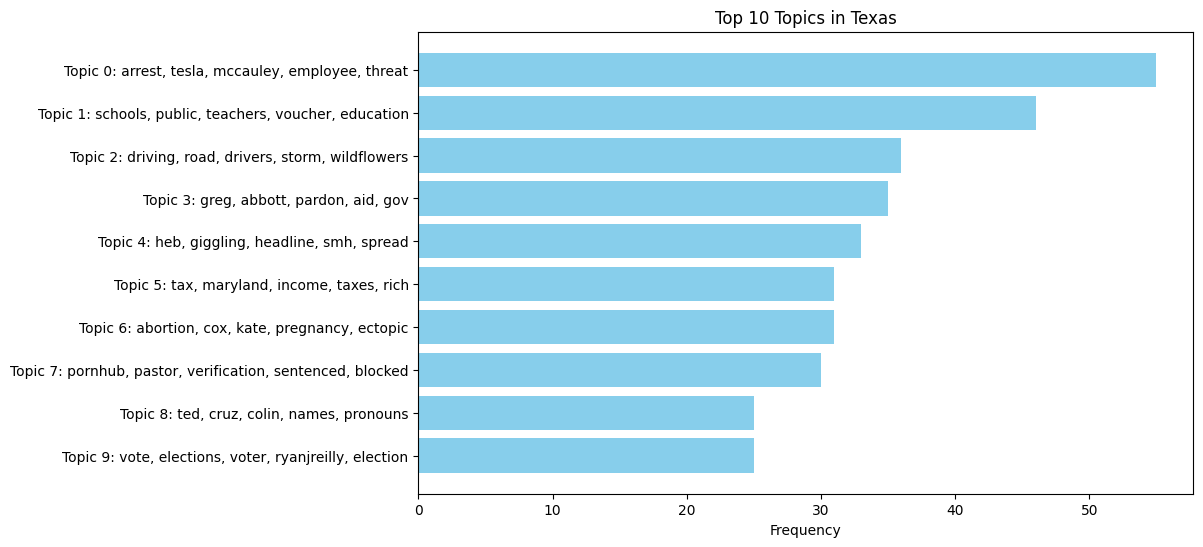

In [12]:
#| label: texas-top-topics
import matplotlib.pyplot as plt

texas_model = models['texas']
topics_info = texas_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in texas_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Texas')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()


In [37]:
# Creating a heatmap, showing how similar a topic is to each other
texas_fig_heatmap = models['texas'].visualize_heatmap()
texas_fig_heatmap.show()

with open('../docs/code_analysis/bert_files/texas/texas-topic-heatmap.html', 'w') as f:
    f.write(texas_fig_heatmap.to_html(include_plotlyjs='cdn'))

In [ ]:
pd.DataFrame(state_data['subreddit'].value_counts())

## Comparing states of Arkansas and Texas

In [52]:
# Assuming state_data contains your dataset for all states
# You can use the same sentence model and UMAP configuration
sentence_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# Define a function to fit BERTopic models for a given state
def fit_bertopic_for_state(state_name, state_data):
    state_text = state_data[state_data['subreddit'] == state_name]['title'].tolist() + \
                 state_data[state_data['subreddit'] == state_name]['selftext'].tolist()
    topic_model = BERTopic(embedding_model=sentence_model, umap_model=umap_model)
    topics, probabilities = topic_model.fit_transform(state_text)
    return topic_model

# Assuming pre-fitted BERTopic models for Texas and Arkansas
texas_model = subreddit_models['texas']['model']
arkansas_model = subreddit_models['Arkansas']['model']

# Extract topic embeddings and filter out the generic topic (-1)
texas_embeddings = [texas_model.topic_embeddings_[i] for i in range(len(texas_model.topic_embeddings_)) if i != -1]
arkansas_embeddings = [arkansas_model.topic_embeddings_[i] for i in range(len(arkansas_model.topic_embeddings_)) if i != -1]

# Calculate the cosine similarity matrix between the topic embeddings of Texas and Arkansas
sim_matrix = cosine_similarity(texas_embeddings, arkansas_embeddings)

# Cluster the similarity matrix to group similar topics
linkage_matrix = linkage(sim_matrix, method='ward')
dendro = dendrogram(linkage_matrix, no_plot=True)
ordered_idx = leaves_list(linkage_matrix)

# Reorder the similarity matrix according to the clustering
sim_matrix_ordered = sim_matrix[:, ordered_idx][ordered_idx]

# Get topic names and filter out the generic topic (-1)
arkansas_topic_names = [topic[1] for topic in arkansas_model.get_topic_info().values.tolist() if topic[0] != -1]
texas_topic_names = [topic[1] for topic in texas_model.get_topic_info().values.tolist() if topic[0] != -1]

# Reorder topic names according to the clustering
arkansas_topic_names_ordered = [arkansas_topic_names[i] for i in ordered_idx]
texas_topic_names_ordered = [texas_topic_names[i] for i in ordered_idx]

# Convert the similarity matrix to a DataFrame for better visualization
sim_df = pd.DataFrame(sim_matrix_ordered, index=texas_topic_names_ordered, columns=arkansas_topic_names_ordered)

# Plot the similarity matrix using Plotly for interactivity
fig = px.imshow(sim_df, color_continuous_scale='RdBu_r', origin='lower', labels=dict(x='Arkansas Topics', y='Texas Topics', color='Cosine Similarity'))
fig.update_layout(title='Cosine Similarity Between Texas and Arkansas Topics')
fig.show()

# Find the indices of the maximum value in the similarity matrix
max_sim_idx = np.unravel_index(np.argmax(sim_matrix, axis=None), sim_matrix.shape)

# Get the most similar topics using the reordered indices
most_similar_texas_topic_num = ordered_idx[max_sim_idx[0]]
most_similar_arkansas_topic_num = ordered_idx[max_sim_idx[1]]

# Find the corresponding topic names
most_similar_texas_topic_name = texas_topic_names_ordered[max_sim_idx[0]]
most_similar_arkansas_topic_name = arkansas_topic_names_ordered[max_sim_idx[1]]

# Print the most similar topics and their similarity score
most_similar_score = sim_matrix_ordered[max_sim_idx[0], max_sim_idx[1]]
# Print the most similar topics and their similarity score without rounding up
print(f"Most similar topics:\nTexas Topic: {most_similar_texas_topic_num} ({most_similar_texas_topic_name})\nArkansas Topic: {most_similar_arkansas_topic_num} ({most_similar_arkansas_topic_name})\nCosine Similarity: {most_similar_score:.4f}")

with open('../docs/code_analysis/bert_files/texas-arkansas-comp.html', 'w') as f:
    f.write(fig.to_html(include_plotlyjs='cdn'))

Most similar topics:
Texas Topic: 1 (384)
Arkansas Topic: 1 (372)
Cosine Similarity: 0.9999


Cosine Similarity between Topic 0 of Texas and Topic 0 of Arkansas: 0.66


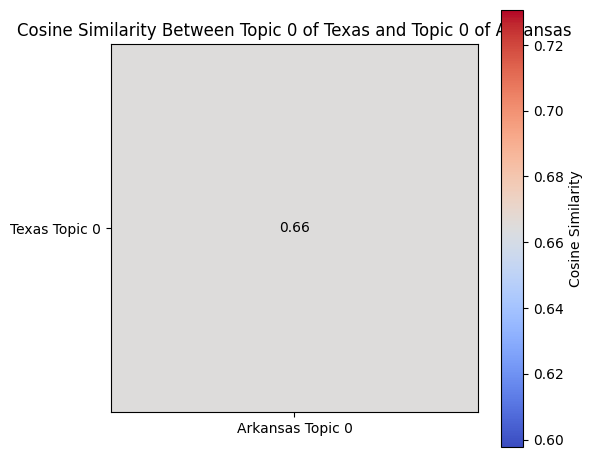

In [53]:
# Assuming your pre-existing BERTopic models are stored in subreddit_models
# subreddit_models[subreddit] = {'model': model, 'topics': topics, 'probabilities': probabilities}

# Load pre-existing BERTopic models for Texas and Arkansas
texas_model = subreddit_models['texas']['model']
arkansas_model = subreddit_models['Arkansas']['model']

# Extract topic embeddings for topic 0
texas_topic_0_embedding = texas_model.topic_embeddings_[0]
arkansas_topic_0_embedding = arkansas_model.topic_embeddings_[0]

# Calculate the cosine similarity between topic 0 from Texas and topic 0 from Arkansas
similarity_score = cosine_similarity([texas_topic_0_embedding], [arkansas_topic_0_embedding])[0, 0]

# Display the similarity score
print(f"Cosine Similarity between Topic 0 of Texas and Topic 0 of Arkansas: {similarity_score:.2f}")

# Plot the similarity score as a heatmap for visual reference
plt.figure(figsize=(6, 5))
plt.imshow([[similarity_score]], cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title('Cosine Similarity Between Topic 0 of Texas and Topic 0 of Arkansas')

# Annotate the similarity score on the heatmap
plt.text(0, 0, f"{similarity_score:.2f}", ha='center', va='center', color='black')

# Set ticks and labels
plt.xticks(ticks=[0], labels=['Arkansas Topic 0'])
plt.yticks(ticks=[0], labels=['Texas Topic 0'])

plt.tight_layout()
plt.show()

--------------

### State 3 - Florida

In [14]:
# Gets the common topics of r/florida
models['florida'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,129,-1_com_pool_gun_reporting,"[com, pool, gun, reporting, plan, fired, lane,...","[Im 23 making 75k year salary, market house. W..."
1,0,136,0_live_lived_beach_storm,"[live, lived, beach, storm, north, place, texa...",[I lived Palm Beach 4 years never understand p...
2,1,83,1_ron_desantis_campaign_biden,"[ron, desantis, campaign, biden, trump, presid...","[DeSantis attending FAMiLY Leadership Summit, ..."
3,2,46,2_motorist_puppy_tree_turnpike,"[motorist, puppy, tree, turnpike, mannered, ma...","[4:45 AM?!? Who fuck thought good idea??, Some..."
4,3,42,3_insurance_premiums_homeowners_increase,"[insurance, premiums, homeowners, increase, lo...","[They ruined Florida. It’s unlivable now, resi..."
5,4,41,4_schools_teacher_bible_books,"[schools, teacher, bible, books, liberty, gend...",[New Florida law kicks today (July 1) allows b...
6,5,26,5_disney_district_takeover_creek,"[disney, district, takeover, creek, reedy, fir...",[DeSantis' 'War Woke' Backfires As Disney Ends...
7,6,25,6_abortion_ballot_marijuana_amendment,"[abortion, ballot, marijuana, amendment, 2024,...","[Florida Supreme Court allows abortion, mariju..."
8,7,17,7_data_covid_measles_fda,"[data, covid, measles, fda, outbreak, vaccine,...",[‘That decision cost lives’: Covid data case d...
9,8,15,8_heat_lawmakers_ban_zaps,"[heat, lawmakers, ban, zaps, monuments, punish...",[Florida’s Anti-Drag Bill Is So Extreme It Wou...


In [15]:
models['florida'].get_representative_docs(1)

['DeSantis attending FAMiLY Leadership Summit, former FOX News host Tucker Carlson hosting "2024 Republican primary forum", DeSantis participating in. More broadly, FAMiLY Leadership Summit founded anti-LGBT, antifeminist, "pro-life" evangelical Christian \\[cult\\] leader James Dobson Jr.; DeSantis subscribes Dobson\'s views, also using summit host similar "pro-life" leaders Governor\'s Mansion Tallahassee. Ron DeSantis cares far campaign Floridians.',
 'DeSantis’ lawyer initially claimed state Florida simply trying stop companies making employees go trainings espousing ideas Ron DeSantis Republican-controlled Legislature find offensive. But — judge points narrower way accomplish — DeSantis lawyer acknowledges real goal: To stop kind trainings entirely. In words, Ron DeSantis isn’t trying stop companies talking systemic racism individual employees don’t want hear it. He’s trying stop companies talking systemic racism employees all. This confession seemed stun judges.',
 'Where all rag

In [38]:
# creates a cluster plot of texts and their respective topics/ interactive
florida_fig_topics = models['florida'].visualize_topics()
florida_fig_topics.show()

with open('../docs/code_analysis/bert_files/florida/florida-topic-map.html', 'w') as f:
    f.write(florida_fig_topics.to_html(include_plotlyjs='cdn'))

In [39]:
# Creates a hierarchical clustering figure of r/florida
florida_fig_hierarchy = models['florida'].visualize_hierarchy()
florida_fig_hierarchy.show()

with open('../docs/code_analysis/bert_files/florida/florida-topic-hierarchy.html', 'w') as f:
    f.write(florida_fig_hierarchy.to_html(include_plotlyjs='cdn'))

In [40]:
#Create barcharts of every topic, showing its most common word
florida_fig_barchart = models['florida'].visualize_barchart(top_n_topics=10)
florida_fig_barchart.show()

with open('../docs/code_analysis/bert_files/florida/florida-topic-bar.html', 'w') as f:
    f.write(florida_fig_barchart.to_html(include_plotlyjs='cdn'))

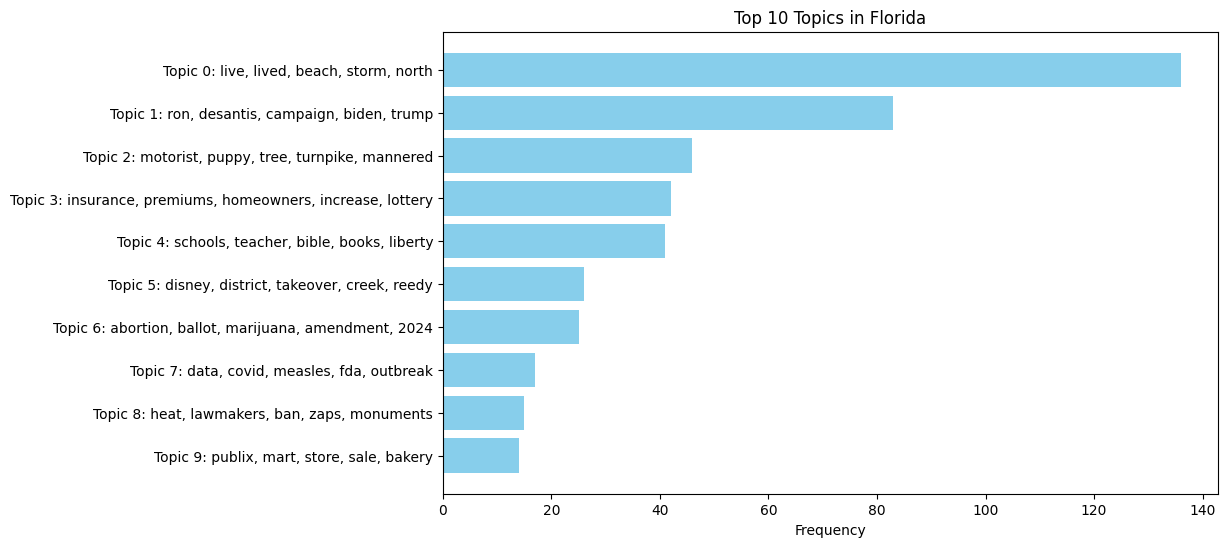

In [19]:
#| label: florida-top-topics
import matplotlib.pyplot as plt

florida_model = models['florida']
topics_info = florida_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in florida_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Florida')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()

In [41]:
florida_fig_heatmap = models['florida'].visualize_heatmap()
florida_fig_heatmap.show()

with open('../docs/code_analysis/bert_files/florida/florida-topic-heatmap.html', 'w') as f:
    f.write(florida_fig_heatmap.to_html(include_plotlyjs='cdn'))

### State 4 - Indiana

In [21]:
# Gets the common topics of r/Arkansas
models['Indiana'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165,-1_gary_todd_cake_kids,"[gary, todd, cake, kids, state, holcomb, medic...","[So, Todd Young's office inside building DR. I..."
1,0,218,0_daylight_indiana_park_state,"[daylight, indiana, park, state, dst, indianap...",[Maybe putting universe help…(!) I met guy las...
2,1,76,1_cannabis_marijuana_legalization_hemp,"[cannabis, marijuana, legalization, hemp, lawm...",[Wabash Valley Resources seeking one two class...
3,2,55,2_scored_team_son_respect,"[scored, team, son, respect, stats, tst, repos...","[Just dropping get company misery, I guess., M..."
4,3,36,3_books_schools_students_teachers,"[books, schools, students, teachers, religious...","[Today, I received letter daughter's school. P..."
5,4,33,4_braun_mike_claims_trump,"[braun, mike, claims, trump, gop, images, cand...",[Got email Senator Braun today keeps voting ag...
6,5,27,5_arrested_officer_charges_pornography,"[arrested, officer, charges, pornography, otte...",[&gt; Indiana Republican Joshua Craft arrested...
7,6,21,6_gender_transgender_minors_court,"[gender, transgender, minors, court, dysphoria...","[The parents, self-described devout Christians..."
8,7,18,7_abortion_violence_ban_org,"[abortion, violence, ban, org, abortions, idah...",[The [Hoosier Abortion Fund](https://alloption...
9,8,13,8_pence_mike_nra_hilarious,"[pence, mike, nra, hilarious, ranch, exile, en...",[Former Vice President Mike Pence ends campaig...


In [22]:
models['Indiana'].get_representative_docs(1)

['Wabash Valley Resources seeking one two class IV carbon sequestration well permits issued EPA. Basically fossil fuels industry wants still use fossil fuels, know can’t get away letting float away atmosphere much longer. So instead going liquify carbon dioxide pump 4,800’ ground. Their plan use porous dolomite rock layers store carbon dioxide hope less pervious layers top don’t crack leak. The problem one really done scale before. Even successful first years, really isn’t much oversight indiana groundwater begin protections place detect leak. Carbon dioxide leaks bad, gets groundwater raises PH. Acidic water dissolve rocks chemicals become contaminated. There also risk carbon dioxide stored impurities oil coal has, could also poison groundwater. Indiana never place known great environment. We fight battles small gains, state leans certain way people don’t pay attention politics. However project worth attention. Carbon sequestration temporary solution long term problem, oil space store

In [43]:
# creates a cluster plot of texts and their respective topics/ interactive
indiana_fig_topics = models['Indiana'].visualize_topics()
indiana_fig_topics.show()

with open('../docs/code_analysis/bert_files/indiana/indiana-topic-map.html', 'w') as f:
    f.write(indiana_fig_topics.to_html(include_plotlyjs='cdn'))

In [44]:
# Creates a hierarchical clustering figure of r/florida
indiana_fig_hierarchy = models['Indiana'].visualize_hierarchy()
indiana_fig_hierarchy.show()

with open('../docs/code_analysis/bert_files/indiana/indiana-topic-hierarchy.html', 'w') as f:
    f.write(indiana_fig_hierarchy.to_html(include_plotlyjs='cdn'))

In [45]:
#Create barcharts of every topic, showing its most common word
indiana_fig_barchart = models['Indiana'].visualize_barchart(top_n_topics=10)
indiana_fig_barchart.show()

with open('../docs/code_analysis/bert_files/indiana/indiana-topic-bar.html', 'w') as f:
    f.write(indiana_fig_barchart.to_html(include_plotlyjs='cdn'))

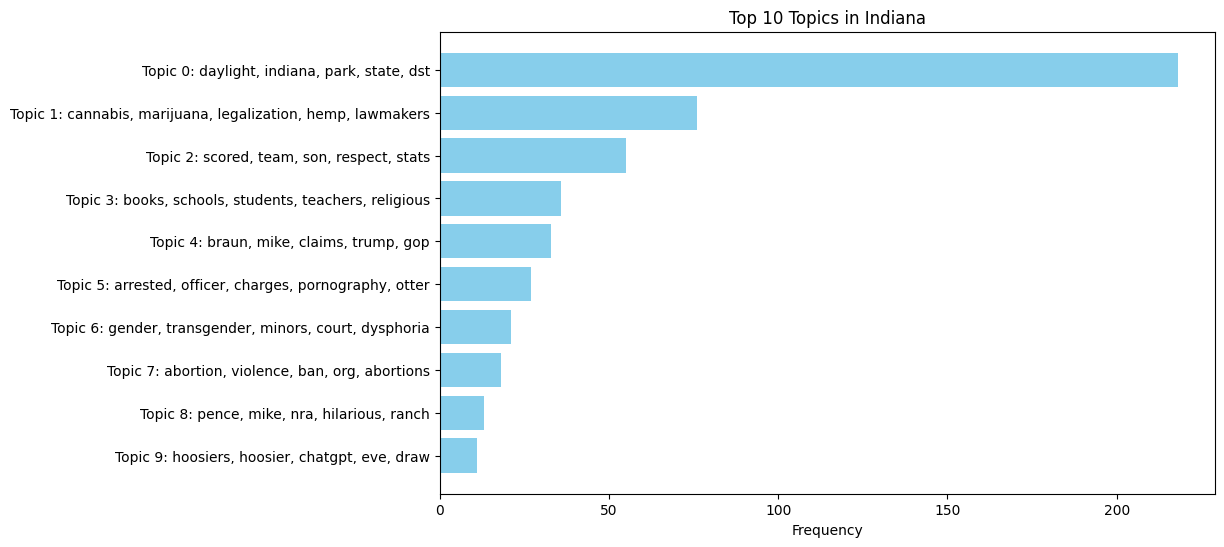

In [46]:
#| label: indiana-top-topics
import matplotlib.pyplot as plt

indiana_model = models['Indiana']
topics_info = indiana_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in indiana_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Indiana')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()

In [47]:
# Creating a heatmap, showing how similar a topic is to each other
indiana_fig_heatmap = models['Indiana'].visualize_heatmap()
indiana_fig_heatmap.show()

with open('../docs/code_analysis/bert_files/indiana/indiana-topic-heatmap.html', 'w') as f:
    f.write(indiana_fig_heatmap.to_html(include_plotlyjs='cdn'))

In [56]:
# Assuming pre-fitted BERTopic models for Florida and Indiana
florida_model = subreddit_models['florida']['model']
indiana_model = subreddit_models['Indiana']['model']

# Extract topic embeddings and filter out the generic topic (-1)
florida_embeddings = np.array([florida_model.topic_embeddings_[i] for i in range(len(florida_model.topic_embeddings_)) if i != -1])
indiana_embeddings = np.array([indiana_model.topic_embeddings_[i] for i in range(len(indiana_model.topic_embeddings_)) if i != -1])

# Verify embeddings are not identical and have correct dimensions
print("Florida Embeddings Shape:", florida_embeddings.shape)
print("Indiana Embeddings Shape:", indiana_embeddings.shape)

# Manually verify a few cosine similarities to ensure correctness
manual_sim = cosine_similarity([florida_embeddings[0]], [indiana_embeddings[0]])
print("Manual Cosine Similarity Check:", manual_sim)

# Calculate the cosine similarity matrix between the topic embeddings of Florida and Indiana
sim_matrix = cosine_similarity(florida_embeddings, indiana_embeddings)

# Convert the similarity matrix to a DataFrame for better visualization
florida_topic_info = pd.DataFrame(florida_model.get_topic_info())
indiana_topic_info = pd.DataFrame(indiana_model.get_topic_info())

# Filter out the generic topic (-1) and get topic names
florida_topic_names = florida_topic_info[florida_topic_info['Topic'] != -1]['Name'].tolist()
indiana_topic_names = indiana_topic_info[indiana_topic_info['Topic'] != -1]['Name'].tolist()

# Create a DataFrame for the similarity matrix
sim_df = pd.DataFrame(sim_matrix, index=florida_topic_names, columns=indiana_topic_names)

# Plot the similarity matrix using Plotly for interactivity
fig = px.imshow(sim_df, color_continuous_scale='RdBu_r', origin='lower', labels=dict(x='Indiana Topics', y='Florida Topics', color='Cosine Similarity'))
fig.update_layout(title='Cosine Similarity Between Florida and Indiana Topics')
fig.show()

# Find the indices of the maximum value in the similarity matrix
max_sim_idx = np.unravel_index(np.argmax(sim_matrix, axis=None), sim_matrix.shape)

# Get the most similar topics using the original indices
most_similar_florida_topic_num = max_sim_idx[0]
most_similar_indiana_topic_num = max_sim_idx[1]

# Find the corresponding topic names
most_similar_florida_topic_name = florida_topic_names[most_similar_florida_topic_num]
most_similar_indiana_topic_name = indiana_topic_names[most_similar_indiana_topic_num]

# Print the most similar topics and their similarity score without rounding up
most_similar_score = sim_matrix[most_similar_florida_topic_num, most_similar_indiana_topic_num]
print(f"Most similar topics:\nFlorida Topic: {most_similar_florida_topic_num} ({most_similar_florida_topic_name})\nIndiana Topic: {most_similar_indiana_topic_num} ({most_similar_indiana_topic_name})\nCosine Similarity: {most_similar_score:.6f}")

with open('../docs/code_analysis/bert_files/florida-indiana-comp.html', 'w') as f:
    f.write(fig.to_html(include_plotlyjs='cdn'))

Florida Embeddings Shape: (2, 384)
Indiana Embeddings Shape: (2, 384)
Manual Cosine Similarity Check: [[0.6166565]]


Most similar topics:
Florida Topic: 1 (1_have_friday_unreal_you)
Indiana Topic: 1 (1_zoinks_ind_everybody_attacked)
Cosine Similarity: 0.999952


# Cross Analysing all States

In [57]:
# Define buzzwords 
buzzwords = ['abortion', 'democrat' 'republican', 'cops', 'marijuana', 'senate','president','shooting','gun','senate', 'war', 'election', 'Biden', 'Trump', 'cannabis', 'immigration']

# Function to parse top topics for buzzwords and return states where they occur
# Function to parse top topics for buzzwords and return states where they occur
def parse_topics_for_buzzwords_with_states(subreddit_models):
    buzzword_states = {buzzword: [] for buzzword in buzzwords}
    for state, model_data in subreddit_models.items():
        model = model_data['model']
        topics = model.get_topic_info()
        for index, topic in topics.iterrows():
            topic_name = topic['Name'].lower()  # Convert topic name to lowercase
            for buzzword in buzzwords:
                if buzzword.lower() in topic_name:  # Check if buzzword is a substring of topic name
                    buzzword_states[buzzword].append(state)
    return buzzword_states



# Get buzzword states for all states and topics
buzzword_states = parse_topics_for_buzzwords_with_states(subreddit_models)

# Count buzzword occurrences across states
common_buzzword_states = {}
for buzzword, states in buzzword_states.items():
    common_buzzword_states[buzzword] = (len(states), states)

# Sort common buzzwords based on counts
sorted_buzzwords = sorted(common_buzzword_states.items(), key=lambda x: x[1][0], reverse=True)

# Get the top 5 common buzzwords
top_common_buzzwords = sorted_buzzwords[:5]

# Print buzzword counts and states
print("Buzzword Counts and States:")
for buzzword, (count, states) in common_buzzword_states.items():
    print(f"{buzzword}: {count} (Seen in: {', '.join(states)})")

# Print top 5 common buzzwords
print("Top 5 Common Sociopolitical Buzzwords Across States:")
for buzzword, (count, states) in top_common_buzzwords:
    print(f"{buzzword}: {count} (Seen in: {', '.join(states)})")


Buzzword Counts and States:
abortion: 2 (Seen in: politics, southcarolina)
democratrepublican: 0 (Seen in: )
cops: 0 (Seen in: )
marijuana: 2 (Seen in: Louisiana, southcarolina)
senate: 6 (Seen in: Pennsylvania, Pennsylvania, newjersey, newjersey, politics, politics)
president: 0 (Seen in: )
shooting: 1 (Seen in: politics)
gun: 1 (Seen in: politics)
war: 1 (Seen in: Washington)
election: 0 (Seen in: )
Biden: 3 (Seen in: politics, politics, southcarolina)
Trump: 4 (Seen in: democrats, politics, politics, southcarolina)
cannabis: 1 (Seen in: southcarolina)
immigration: 0 (Seen in: )
Top 5 Common Sociopolitical Buzzwords Across States:
senate: 6 (Seen in: Pennsylvania, Pennsylvania, newjersey, newjersey, politics, politics)
Trump: 4 (Seen in: democrats, politics, politics, southcarolina)
Biden: 3 (Seen in: politics, politics, southcarolina)
abortion: 2 (Seen in: politics, southcarolina)
marijuana: 2 (Seen in: Louisiana, southcarolina)


# Trending topics in each state

In [60]:
# Group by subreddit and find the row with the maximum ups in each group
most_popular_posts = state_data.loc[state_data.groupby('subreddit')['ups'].idxmax()]

# Display the most popular post in each state
table = most_popular_posts[['subreddit', 'title', 'ups']]
table.columns = ['State', 'Title', 'Upvotes']
print(tabulate(table, headers='keys', tablefmt='grid'))

+-------+---------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|       | State         | Title                                                                                                                                                                                                                                                                            |   Upvotes |
+=======+===============+==================================================================================================================================================================================================================================================================================+===========+
|  9000 | Alabama       | Small-town police sued for planting

# Created a database for interactive map

In [ ]:
# Create and connect to the first SQLite database
conn1 = sqlite3.connect('state_subreddit_data.db')
cur1 = conn1.cursor()

# Create the database table for subreddit data
cur1.execute('''
    CREATE TABLE IF NOT EXISTS subreddit_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        subreddit TEXT NOT NULL,
        title TEXT NOT NULL,
        upvote_ratio REAL NOT NULL,
        upvotes INTEGER NOT NULL,
        num_comments INTEGER NOT NULL
    )
''')

# Insert data into the database
for index, row in state_data.iterrows():
    cur1.execute('''
        INSERT INTO subreddit_data (subreddit, title, upvote_ratio, upvotes, num_comments)
        VALUES (?, ?, ?, ?, ?)
    ''', (row['subreddit'], row['title'], row['upvote_ratio'], row['ups'], row['num_comments']))

# Commit the changes and close the connection
conn1.commit()
conn1.close()

print("Subreddit data inserted successfully.")

# Function to get the top 3 topics for a state
def get_top_topics(model):
    topics = model.get_topic_info().head(3)
    return topics['Name'].tolist()

# Create and connect to the second SQLite database
conn2 = sqlite3.connect('state_topics_data.db')
cur2 = conn2.cursor()

# Create the database table for state topics data
cur2.execute('''
    CREATE TABLE IF NOT EXISTS state_topics (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        state TEXT NOT NULL,
        topic1 TEXT,
        topic2 TEXT,
        topic3 TEXT
    )
''')

# Insert data into the database
for state, model in models.items():
    top_topics = get_top_topics(model)
    topic1, topic2, topic3 = top_topics if len(top_topics) == 3 else (top_topics + [None] * (3 - len(top_topics)))
    cur2.execute('''
        INSERT INTO state_topics (state, topic1, topic2, topic3)
        VALUES (?, ?, ?, ?)
    ''', (state, topic1, topic2, topic3))

# Commit the changes and close the connection
conn2.commit()
conn2.close()

print("State topics data inserted successfully.")

# Reconnect to the databases
conn1 = sqlite3.connect('state_subreddit_data.db')
cur1 = conn1.cursor()

conn2 = sqlite3.connect('state_topics_data.db')
cur2 = conn2.cursor()

# Create and connect to the final merged database
conn_final = sqlite3.connect('merged_state_data.db')
cur_final = conn_final.cursor()

# Create the database table for the merged data
cur_final.execute('''
    CREATE TABLE IF NOT EXISTS merged_state_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        state TEXT NOT NULL,
        top_subreddit TEXT NOT NULL,
        title TEXT NOT NULL,
        upvote_ratio REAL NOT NULL,
        upvotes INTEGER NOT NULL,
        num_comments INTEGER NOT NULL,
        topic1 TEXT,
        topic2 TEXT,
        topic3 TEXT
    )
''')

# Merge data from the two databases
cur1.execute('SELECT * FROM subreddit_data')
subreddit_data = cur1.fetchall()

for row in subreddit_data:
    subreddit = row[1]
    title = row[2]
    upvote_ratio = row[3]
    upvotes = row[4]
    num_comments = row[5]

    cur2.execute('SELECT * FROM state_topics WHERE state = ?', (subreddit,))
    topics = cur2.fetchone()
    if topics:
        state = topics[1]
        topic1 = topics[2]
        topic2 = topics[3]
        topic3 = topics[4]
    else:
        state = subreddit
        topic1 = None
        topic2 = None
        topic3 = None

    cur_final.execute('''
        INSERT INTO merged_state_data (state, top_subreddit, title, upvote_ratio, upvotes, num_comments, topic1, topic2, topic3)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (state, subreddit, title, upvote_ratio, upvotes, num_comments, topic1, topic2, topic3))

# Commit the changes and close the connections
conn_final.commit()
conn_final.close()
conn1.close()
conn2.close()

print("Data merged successfully.")


# Connect to the merged database
conn = sqlite3.connect('merged_state_data.db')
cur = conn.cursor()

# Query the merged data
cur.execute('SELECT * FROM merged_state_data')
rows = cur.fetchall()

# Get the column names
column_names = [description[0] for description in cur.description]

# Load data into a DataFrame for better formatting
merged_data = pd.DataFrame(rows, columns=column_names)


# Close the connection
conn.close()

# Select the top post for each state by the number of upvotes
top_posts = merged_data.loc[merged_data.groupby('state')['upvotes'].idxmax()]


# Drop the 'top_subreddit' column
top_posts = top_posts.drop(columns=['top_subreddit'])
top_posts = top_posts.rename(columns={'title': 'name of top subreddit'})
# Filter out the row where the state is labeled 'politics'
top_posts = top_posts[top_posts['state'] != 'politics']
# Print the final DataFrame
print(top_posts)

# Save the DataFrame to a CSV file

# Convert top_posts to a DataFrame (if it's not already one)
top_posts_df = pd.DataFrame(top_posts)

# Save the DataFrame to a CSV file
top_posts_df.to_csv('top_posts.csv', index=False)

print("Top posts saved as 'top_posts.csv'")

